In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="coolwarm", font_scale=1.1)
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("London_Cleaned_Preprocessed.csv")
print("Dataset Loaded Successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns[:10].tolist())
print("\nMissing Values:", df.isnull().sum().sum())
num_cols = ['Price', 'Area in sq ft', 'No. of Bedrooms',
            'No. of Bathrooms', 'No. of Receptions', 'Price_per_sqft']
print("\n Descriptive Statistics:\n")
print(df[num_cols].describe())

Saving London_Cleaned_Preprocessed.csv to London_Cleaned_Preprocessed.csv
Dataset Loaded Successfully!
Shape: (3223, 786)
Columns: ['Property Name', 'Price', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Postal Code', 'Postal Area', 'Price_per_sqft', 'House Type_Duplex']

Missing Values: 0

 Descriptive Statistics:

              Price  Area in sq ft  No. of Bedrooms  No. of Bathrooms  \
count  3.223000e+03   3.223000e+03     3.223000e+03      3.223000e+03   
mean   1.190484e-16   3.306901e-17    -1.234576e-16     -1.234576e-16   
std    1.000000e+00   1.000000e+00     1.000000e+00      1.000000e+00   
min   -1.388861e+00  -1.236513e+00    -2.062691e+00     -2.062691e+00   
25%   -7.808070e-01  -7.037968e-01    -6.804157e-01     -6.804157e-01   
50%   -2.932163e-01  -3.012777e-01     1.072196e-02      1.072196e-02   
75%    5.270833e-01   4.351831e-01     7.018596e-01      7.018596e-01   
max    3.280537e+00   9.500310e+00     3.466410e+00      3.466410e

In [11]:
# ===========================
# 0. IMPORTS
# ===========================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)



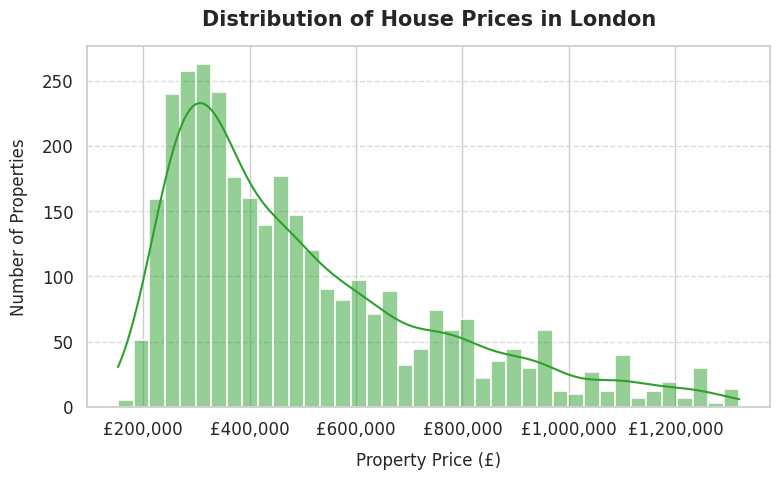

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
price_mean = 500000
price_std = 250000
df['Price (£)'] = (df['Price'] * price_std) + price_mean
plt.figure(figsize=(8,5))
sns.histplot(df['Price (£)'], kde=True, bins=40, color='#2ca02c', edgecolor='white', linewidth=1.2)
plt.title("Distribution of House Prices in London", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Property Price (£)", fontsize=12, labelpad=10)
plt.ylabel("Number of Properties", fontsize=12, labelpad=10)
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

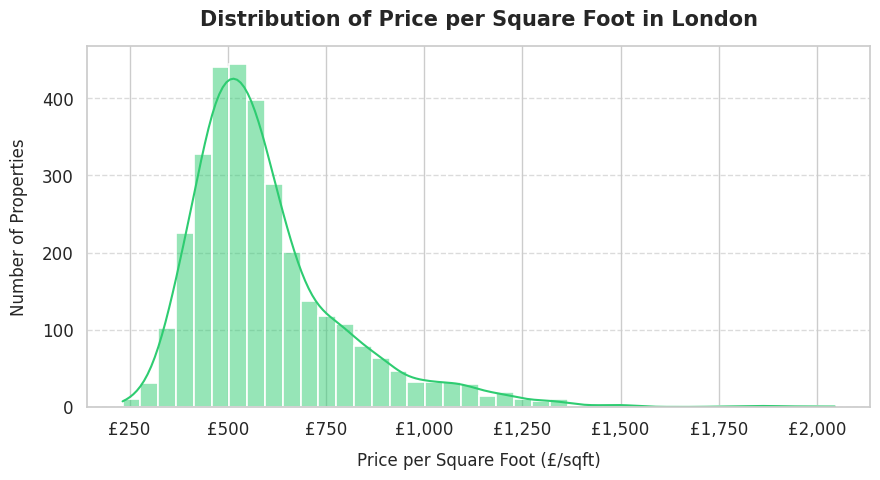

In [46]:
price_sqft_mean = 600
price_sqft_std = 200
df['Price_per_sqft (£/sqft)'] = (df['Price_per_sqft'] * price_sqft_std) + price_sqft_mean
plt.figure(figsize=(9,5))
sns.histplot(
    df['Price_per_sqft (£/sqft)'],
    kde=True,
    bins=40,
    color='#2ecc71',
    edgecolor='white',
    linewidth=1.2
)
plt.title("Distribution of Price per Square Foot in London", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Price per Square Foot (£/sqft)", fontsize=12, labelpad=10)
plt.ylabel("Number of Properties", fontsize=12, labelpad=10)
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

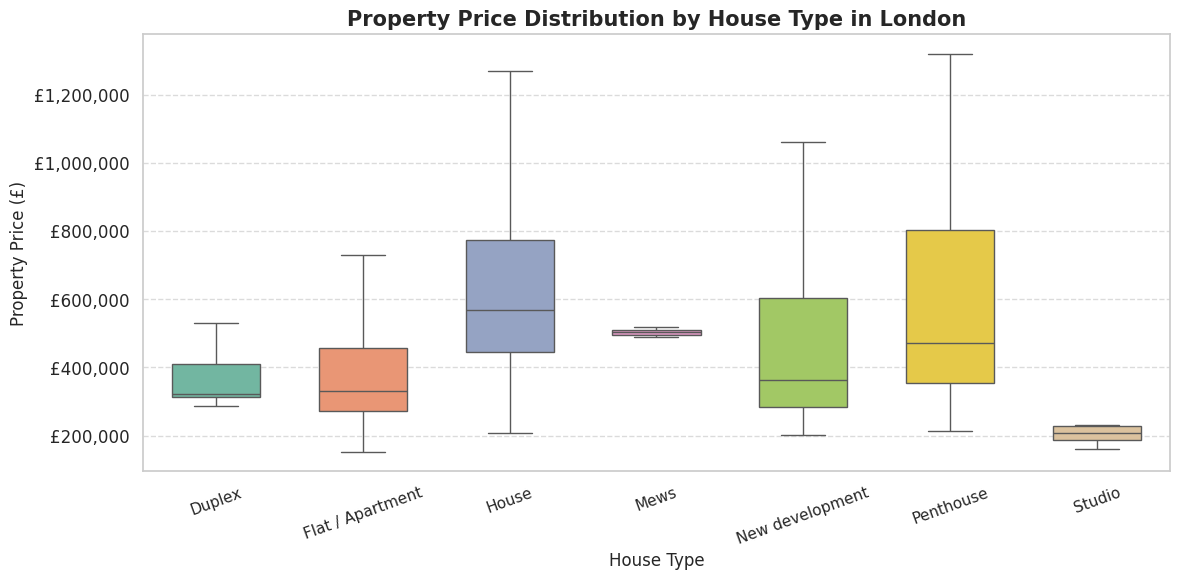

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
house_cols = [col for col in df.columns if "House Type" in col]
house_data = df[['Price (£)'] + house_cols].melt(id_vars='Price (£)', var_name='House Type', value_name='Presence')
house_data = house_data[house_data['Presence'] == 1]
house_data['House Type'] = house_data['House Type'].str.replace('House Type_', '', regex=False)
plt.figure(figsize=(12,6))
sns.boxplot(
    x='House Type',
    y='Price (£)',
    hue='House Type',
    data=house_data,
    palette='Set2',
    width=0.6,
    showfliers=False,
    legend=False
)
plt.title("Property Price Distribution by House Type in London", fontsize=15, fontweight='bold')
plt.xlabel("House Type", fontsize=12)
plt.ylabel("Property Price (£)", fontsize=12)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.xticks(rotation=20, ha='center', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

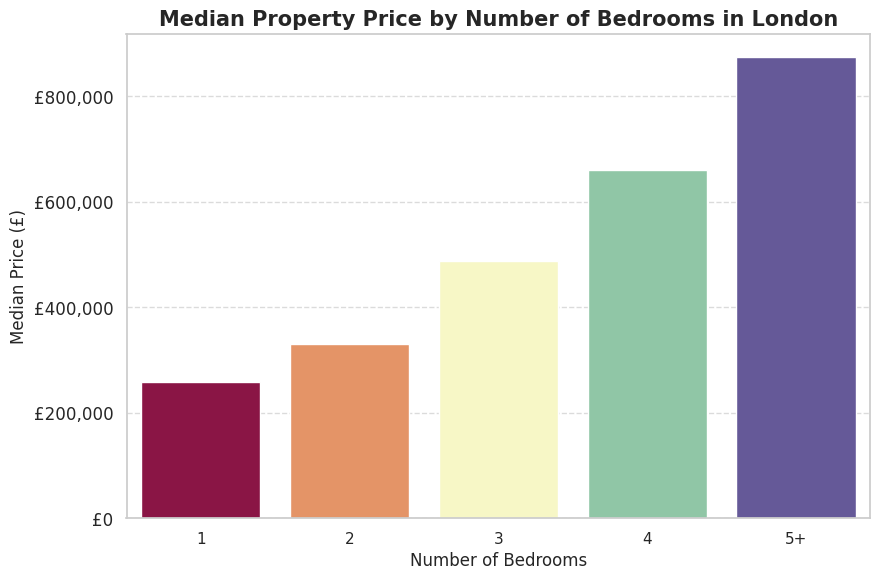

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
bedroom_mean = 2.5
bedroom_std = 1.0
df['Bedrooms (Rounded)'] = np.round((df['No. of Bedrooms'] * bedroom_std) + bedroom_mean).astype(int)
df = df[df['Bedrooms (Rounded)'] > 0]
df.loc[df['Bedrooms (Rounded)'] > 5, 'Bedrooms (Rounded)'] = 5
bedroom_prices = df.groupby('Bedrooms (Rounded)')['Price (£)'].median().reset_index()
plt.figure(figsize=(9,6))
sns.barplot(
    data=bedroom_prices,
    x='Bedrooms (Rounded)',
    y='Price (£)',
    hue='Bedrooms (Rounded)',
    palette='Spectral',
    legend=False
)
plt.title("Median Property Price by Number of Bedrooms in London", fontsize=15, fontweight='bold')
plt.xlabel("Number of Bedrooms", fontsize=12)
plt.ylabel("Median Price (£)", fontsize=12)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
xticklabels = [str(int(x)) if x < 5 else '5+' for x in bedroom_prices['Bedrooms (Rounded)']]
plt.xticks(ticks=range(len(xticklabels)), labels=xticklabels, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

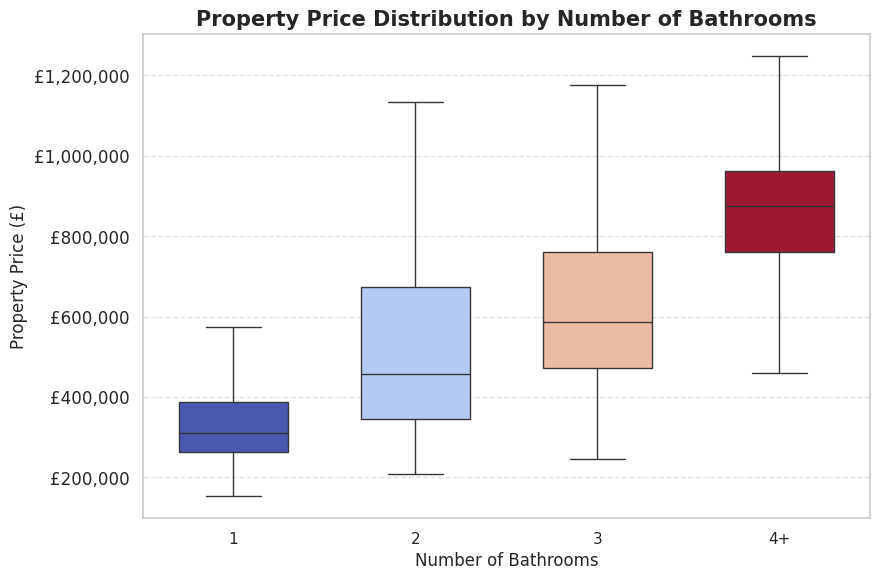

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np
bath_mean = 2.0
bath_std = 0.8
df['Bathrooms (Rounded)'] = np.round((df['No. of Bathrooms'] * bath_std) + bath_mean).astype(int)
df = df[df['Bathrooms (Rounded)'] > 0]
df.loc[df['Bathrooms (Rounded)'] > 4, 'Bathrooms (Rounded)'] = 4
plt.figure(figsize=(9,6))
sns.boxplot(
    x='Bathrooms (Rounded)',
    y='Price (£)',
    hue='Bathrooms (Rounded)',
    data=df,
    palette='coolwarm',
    width=0.6,
    showfliers=False,
    legend=False
)
plt.title("Property Price Distribution by Number of Bathrooms", fontsize=15, fontweight='bold')
plt.xlabel("Number of Bathrooms", fontsize=12)
plt.ylabel("Property Price (£)", fontsize=12)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
xticklabels = [str(int(x)) if x < 4 else '4+' for x in sorted(df['Bathrooms (Rounded)'].unique())]
plt.xticks(ticks=range(len(xticklabels)), labels=xticklabels, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

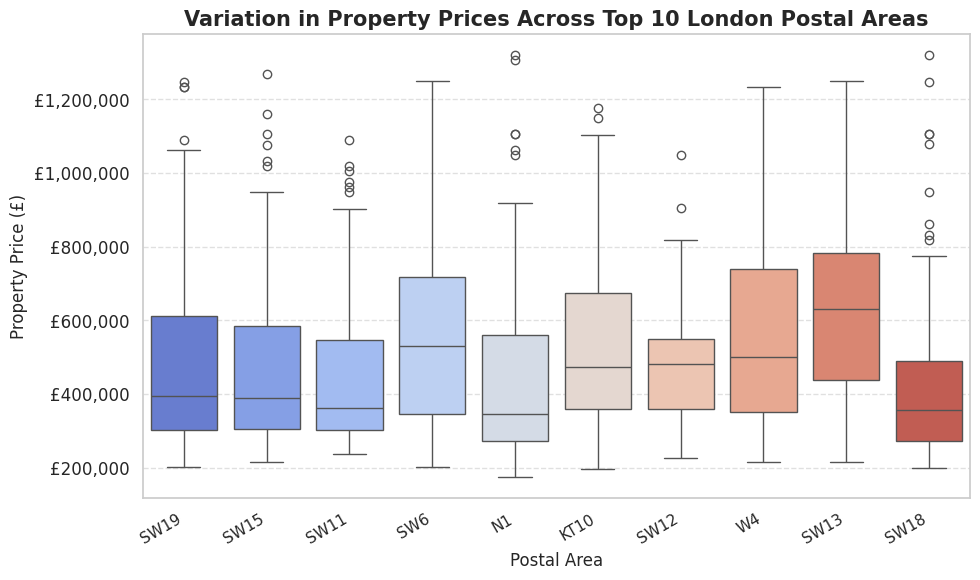

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
top_areas = df['Postal Area'].value_counts().nlargest(10).index
filtered_df = df[df['Postal Area'].isin(top_areas)]
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Postal Area',
    y='Price (£)',
    hue='Postal Area',
    data=filtered_df,
    palette='coolwarm',
    showfliers=True,
    legend=False
)
plt.title("Variation in Property Prices Across Top 10 London Postal Areas", fontsize=15, fontweight='bold')
plt.xlabel("Postal Area", fontsize=12)
plt.ylabel("Property Price (£)", fontsize=12)
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


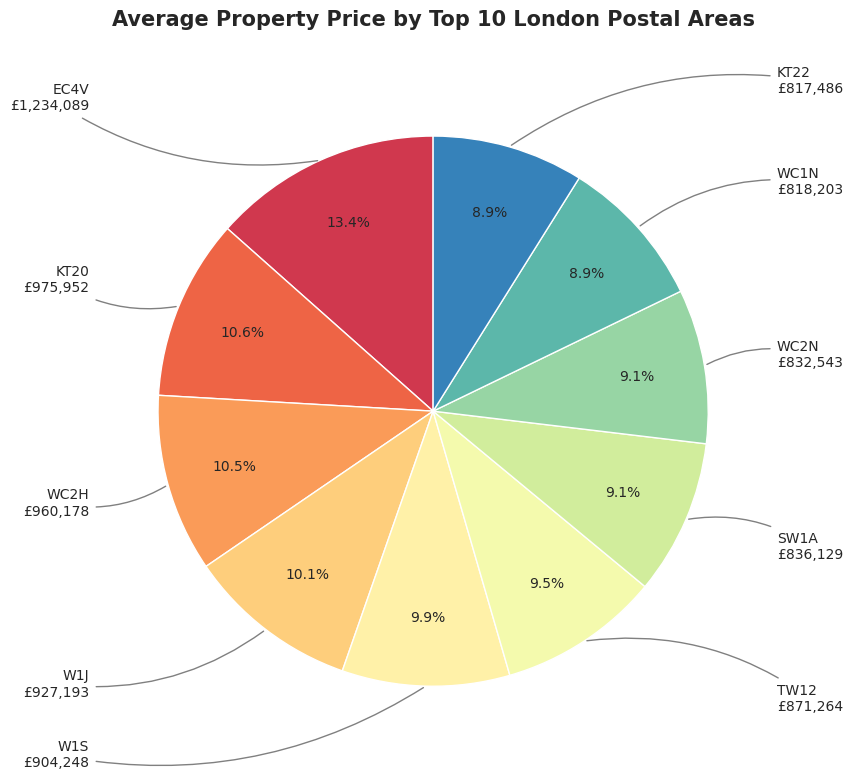

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
top_areas = (
    df.groupby('Postal Area')['Price (£)']
    .mean()
    .nlargest(10)
    .sort_values(ascending=False)
)
colors = sns.color_palette('Spectral', len(top_areas))
plt.figure(figsize=(10,8))
wedges, texts, autotexts = plt.pie(
    top_areas.values,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize': 10}
)
bbox_props = dict(boxstyle="square,pad=0.3", fc="white", ec="none", alpha=0.7)
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    plt.annotate(
        f"{top_areas.index[i]}\n£{top_areas.values[i]:,.0f}",
        xy=(x, y),
        xytext=(1.25*np.sign(x), 1.25*y),
        horizontalalignment=horizontalalignment,
        verticalalignment="center",
        fontsize=10,
        fontweight='medium',
        bbox=bbox_props,
        arrowprops=dict(arrowstyle="-", color='gray', lw=1, connectionstyle="arc3,rad=0.2")
    )
plt.title("Average Property Price by Top 10 London Postal Areas", fontsize=15, fontweight='bold', pad=30)
plt.tight_layout()
plt.show()

Column names found:
 ['Property Name', 'Price', 'Area in sq ft', 'No. of Bedrooms', 'No. of Bathrooms', 'No. of Receptions', 'Postal Code', 'Postal Area', 'Price_per_sqft', 'House Type_Duplex', 'House Type_Flat / Apartment', 'House Type_House', 'House Type_Mews', 'House Type_New development', 'House Type_Penthouse', 'House Type_Studio', 'Location_ 35 Salusbury Road', 'Location_ 352 Queenstown Road', 'Location_ 372 Queenstown Road', 'Location_ Acton', 'Location_ Aldgate', 'Location_ Barbican', 'Location_ Barnes', 'Location_ Barons Court', 'Location_ Barwell Lane', 'Location_ Battersea', 'Location_ Battesea', 'Location_ Bayswater', 'Location_ Belsize Park', 'Location_ Bloomsbury', 'Location_ Bow', 'Location_ Brentford', 'Location_ Brick Lane', 'Location_ Buckhurst Hill', 'Location_ Bushey', 'Location_ Canary Wharf', 'Location_ Canary Wharf;', 'Location_ Chelsea', 'Location_ Chelsea Harbour', 'Location_ Chessington', 'Location_ Chigwell', 'Location_ Chiswick', 'Location_ City Of London', 

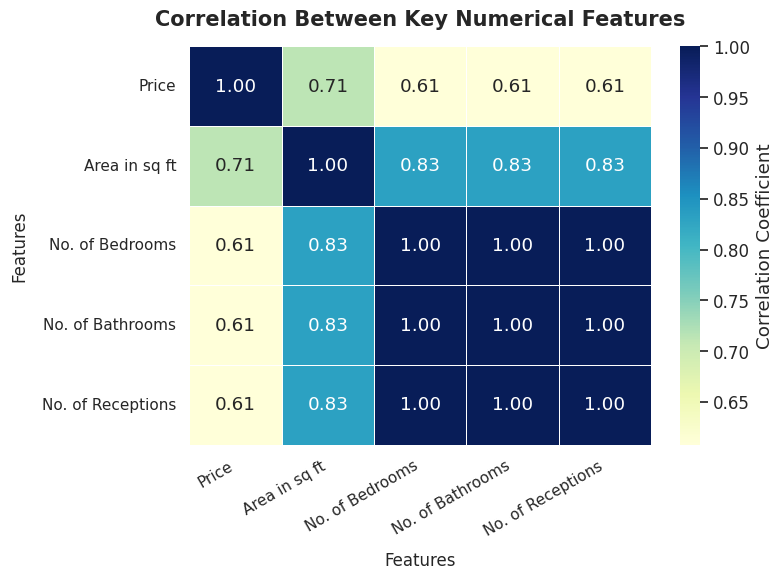

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Column names found:\n", df.columns.tolist())
price_col = next((col for col in df.columns if 'price' in col.lower()), None)
area_col = next((col for col in df.columns if 'area' in col.lower()), None)
bed_col = next((col for col in df.columns if 'bed' in col.lower()), None)
bath_col = next((col for col in df.columns if 'bath' in col.lower()), None)
recept_col = next((col for col in df.columns if 'recep' in col.lower()), None)
print("\nDetected Columns:")
print(f"Price: {price_col}")
print(f"Area: {area_col}")
print(f"Bedrooms: {bed_col}")
print(f"Bathrooms: {bath_col}")
print(f"Receptions: {recept_col}")
corr_features = [c for c in [price_col, area_col, bed_col, bath_col, recept_col] if c is not None]
corr_matrix = df[corr_features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt=".2f",
    linewidths=0.6,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Correlation Between Key Numerical Features", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Features", fontsize=12, labelpad=10)
plt.ylabel("Features", fontsize=12, labelpad=10)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
# 2. PREPARE DATA FOR MODELLING
#    (DROP LEAKAGE COLUMNS)
leakage_cols = [
    "Price_per_sqft",
    "Property Name",
    "Postal Code",
    "Postal Area"
]

df_model = df.drop(columns=leakage_cols)

X = df_model.drop(columns=["Price"])
y = df_model["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3223, 781)
y shape: (3223,)


In [13]:
# 3. TRAIN–TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 2578
Test size: 645


In [32]:
# Use quantiles to create 4 roughly balanced bins
q = y_train.quantile([0.25, 0.5, 0.75])

bins = [-np.inf, q[0.25], q[0.5], q[0.75], np.inf]
labels = ["Very Low", "Low", "High", "Very High"]

y_test_cat = pd.cut(y_test, bins=bins, labels=labels)


=== Linear Regression ===
MAE : 0.36039397856746325
RMSE: 0.5382490901139116
R²  : 0.7307695448829189


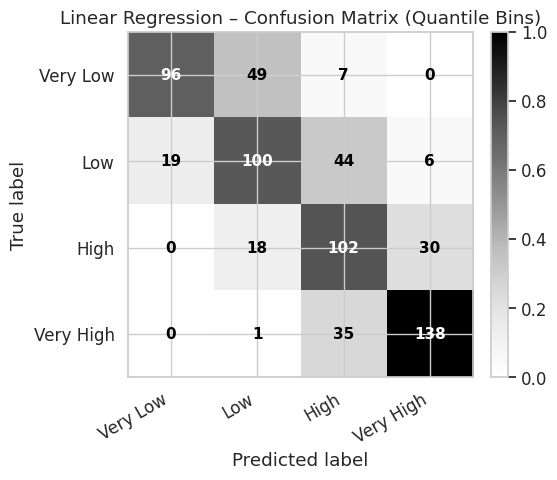

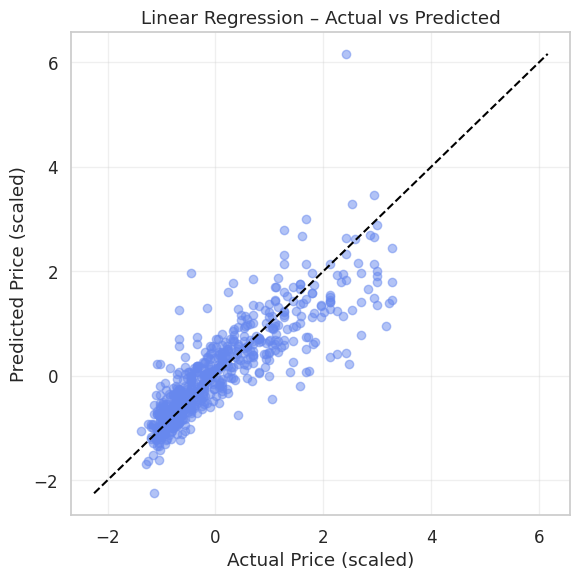

In [44]:
# 1. Linear Regression
def plot_pretty_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm / cm.max()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Greys")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_aspect("equal")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if val > 0.5 else "black"
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

# 6. LINEAR REGRESSION MODEL

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# 7. METRICS
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Linear Regression ===")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


y_pred_cat = pd.cut(y_pred, bins=bins, labels=labels)

plot_pretty_cm(
    y_true=y_test_cat,
    y_pred=y_pred_cat,
    labels=labels,
    title="Linear Regression – Confusion Matrix (Quantile Bins)"
)
# ----- 1. Actual vs Predicted -----
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')  # reference line
plt.xlabel("Actual Price (scaled)")
plt.ylabel("Predicted Price (scaled)")
plt.title("Linear Regression – Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== Ridge Regression ===
MAE : 0.3926818254331856
RMSE: 0.5804793376814826
R²  : 0.6868653640902751


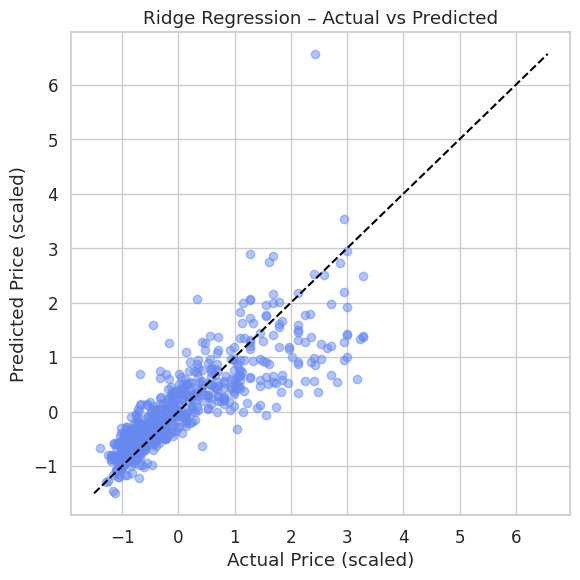

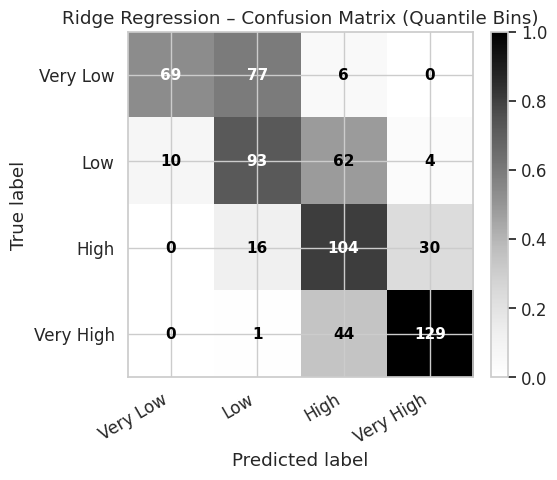

In [38]:
# 2.RIDGE REGRESSION
def plot_pretty_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm / cm.max()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Greys")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_aspect("equal")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if val > 0.5 else "black"
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

# 5. Train Ridge model
ridge = Ridge(alpha=10.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

# 6. Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== Ridge Regression ===")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
# 7. Scatter plot: Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.xlabel("Actual Price (scaled)")
plt.ylabel("Predicted Price (scaled)")
plt.title("Ridge Regression – Actual vs Predicted")
plt.tight_layout()
plt.show()
# 8. Confusion matrix
y_pred_cat = pd.cut(y_pred, bins=bins, labels=labels)
plot_pretty_cm(
    y_true=y_test_cat,
    y_pred=y_pred_cat,
    labels=labels,
    title="Ridge Regression – Confusion Matrix (Quantile Bins)"
)

=== Random Forest ===
MAE : 0.34029028884050233
RMSE: 0.5123122244740985
R²  : 0.756091455615266


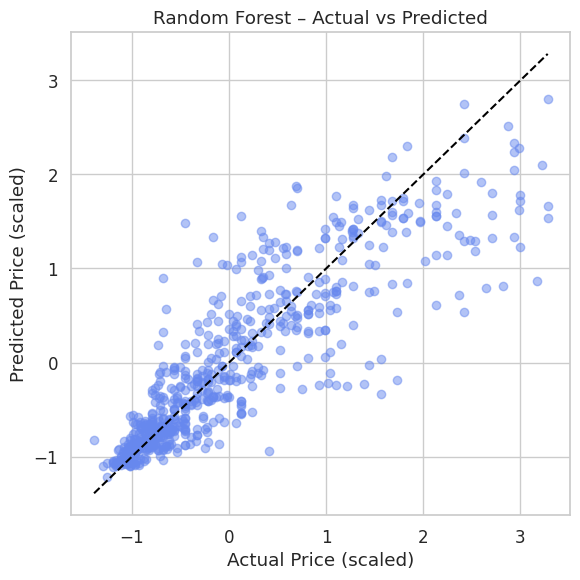

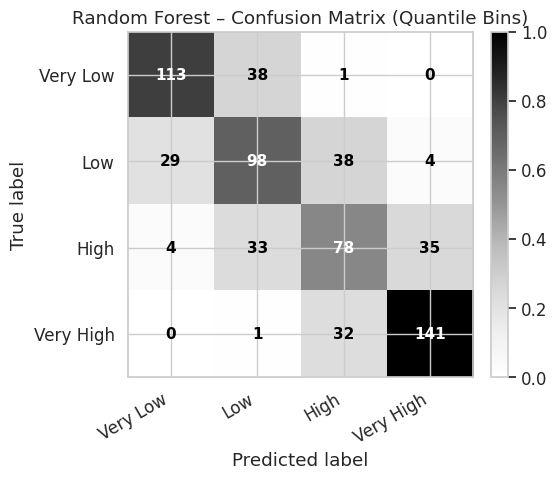

In [39]:
# 3.RANDOM FOREST
def plot_pretty_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm / cm.max()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Greys")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_aspect("equal")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if val > 0.5 else "black"
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()
# 5. Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
# 6. Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print("=== Random Forest ===")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
# 7. Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.xlabel("Actual Price (scaled)")
plt.ylabel("Predicted Price (scaled)")
plt.title("Random Forest – Actual vs Predicted")
plt.tight_layout()
plt.show()
# 8. Confusion matrix
y_pred_cat = pd.cut(y_pred, bins=bins, labels=labels)
plot_pretty_cm(
    y_true=y_test_cat,
    y_pred=y_pred_cat,
    labels=labels,
    title="Random Forest – Confusion Matrix (Quantile Bins)"
)

=== XGBoost ===
MAE : 0.31668133220860123
RMSE: 0.45787331623500155
R²  : 0.8051734025281486


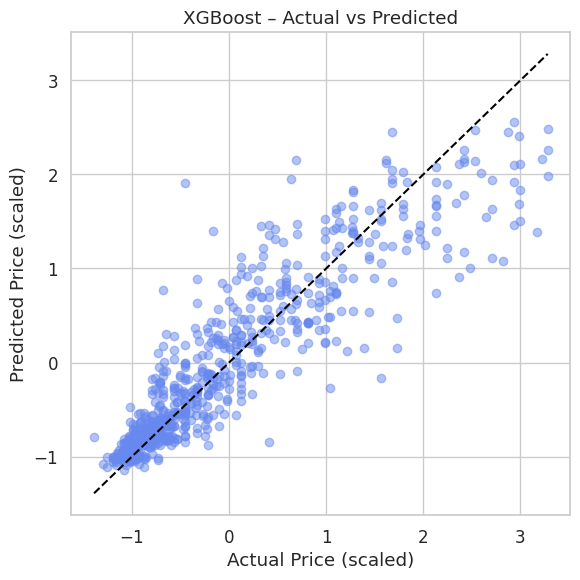

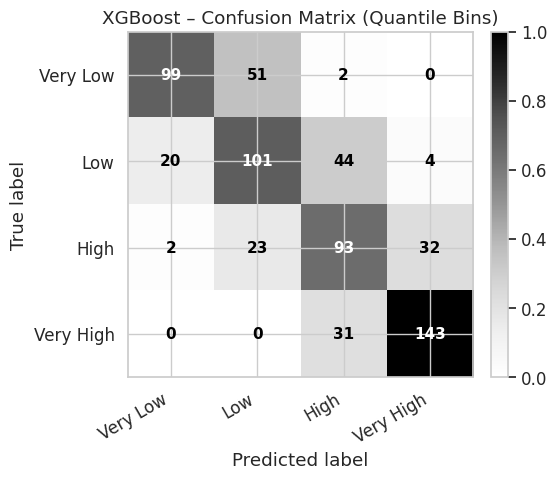

In [40]:
# 4. XG BOOST
def plot_pretty_cm(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm / cm.max()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Greys")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_aspect("equal")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                fontsize=11,
                fontweight="bold",
                color="white" if val > 0.5 else "black"
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()
# 5. Train XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
# 6. Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== XGBoost ===")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)
# 7. Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--")
plt.xlabel("Actual Price (scaled)")
plt.ylabel("Predicted Price (scaled)")
plt.title("XGBoost – Actual vs Predicted")
plt.tight_layout()
plt.show()
# 8. Confusion matrix
y_pred_cat = pd.cut(y_pred, bins=bins, labels=labels)
plot_pretty_cm(
    y_true=y_test_cat,
    y_pred=y_pred_cat,
    labels=labels,
    title="XGBoost – Confusion Matrix (Quantile Bins)"
)

In [42]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

# 1. Linear Regression
results.append([
    "Linear Regression",
    mean_absolute_error(y_test, y_pred_lr),
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    r2_score(y_test, y_pred_lr)
])

# 2. Ridge Regression
results.append([
    "Ridge Regression",
    mean_absolute_error(y_test, y_pred_ridge),
    np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    r2_score(y_test, y_pred_ridge)
])

# 3. Random Forest
results.append([
    "Random Forest",
    mean_absolute_error(y_test, y_pred_rf),
    np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    r2_score(y_test, y_pred_rf)
])

# 4. XGBoost
results.append([
    "XGBoost",
    mean_absolute_error(y_test, y_pred_xgb),
    np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    r2_score(y_test, y_pred_xgb)
])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

results_df


,Model,MAE,RMSE,R² Score
0,Linear Regression,0.360394,0.538249,0.730770
1,Ridge Regression,0.392682,0.580479,0.686865
2,Random Forest,0.340290,0.512312,0.756091
3,XGBoost,0.316681,0.457873,0.805173
